# Project 7 — main report notebook (inference only)

This notebook does **no diffusion training**. It loads the saved checkpoints and reproduces every figure and number in the report.

**Required files** (relative to this notebook):
```
checkpoints/cddpm_linear.pt
checkpoints/cddpm_cosine.pt
checkpoints/mnist_classifier.pt
mnist_custom.pt        (optional: only used for the real-digit reference grid)
```
Figures are written to `figures/`, tables to `results/`.

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import utils

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
CKPT_DIR, FIG_DIR, RES_DIR = 'checkpoints', 'figures', 'results'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)
SAMPLE_SEED = 1337

## Definitions (identical to `DDPM_CosineSchedule.ipynb`)

In [4]:
def extract(a, t, x_shape):
    """
    Extracts coefficients at specified timesteps, then reshapes to [batch_size, 1, 1, 1] for broadcasting purposes
    a: Tensor of shape (num_timesteps) (e.g. alpha_bar)
    t: Tensor of shape (batch_size) with timestep indices
    """
    batch_size = t.shape[0]
    out = a.gather(-1, t).reshape(batch_size, *((1,) * (len(x_shape) - 1)))
    return out

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    """Original DDPM schedule (Ho et al., 2020): beta increases linearly."""
    return torch.linspace(beta_start, beta_end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine schedule (Nichol & Dhariwal, 2021).
    alpha_bar(t) = f(t)/f(0) with f(t) = cos^2( ((t/T + s)/(1 + s)) * pi/2 ),
    and beta_t = 1 - alpha_bar_t / alpha_bar_{t-1}, clipped to avoid a singular last step.
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float64)
    f = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi / 2) ** 2
    alpha_bars = f / f[0]
    betas = 1 - (alpha_bars[1:] / alpha_bars[:-1])
    return torch.clip(betas, 0.0001, 0.999).float()

def make_schedule(name, timesteps):
    """Bundle betas / alphas / alpha_bars of one schedule so the two models never share globals."""
    if name == 'linear':
        betas = linear_beta_schedule(timesteps)
    elif name == 'cosine':
        betas = cosine_beta_schedule(timesteps)
    else:
        raise ValueError(f"Unknown schedule: {name}")
    betas = betas.float().to(device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return {'name': name, 'T': timesteps, 'betas': betas, 'alphas': alphas, 'alpha_bars': alpha_bars}

def q_sample(x0, t, sched, noise=None):
    """Closed-form forward process: x_t = sqrt(alpha_bar_t) x_0 + sqrt(1 - alpha_bar_t) eps."""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha_bar = torch.sqrt(extract(sched['alpha_bars'], t, x0.shape))
    sqrt_one_minus_alpha_bar = torch.sqrt(extract(1 - sched['alpha_bars'], t, x0.shape))
    return sqrt_alpha_bar * x0 + noise * sqrt_one_minus_alpha_bar

In [5]:
channels = 1  # for MNIST (image_size is set from the data / checkpoints)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class UNet_cond(nn.Module):
    """Same architecture as the 9.3 tutorial. Only change: `timesteps` is stored on the model
    (instead of read from a global) so each checkpoint normalises t with its own T."""
    def __init__(self, ch=32, n_classes=10, timesteps=1000):
        super().__init__()
        self.timesteps = timesteps
        # encoder
        self.enc1 = ConvBlock(channels, ch)
        self.enc2 = ConvBlock(ch, ch*2)
        # bottleneck
        self.bot = ConvBlock(ch*2, ch*2)
        # decoder
        self.dec2 = ConvBlock(ch*2 + ch*2, ch)
        self.dec1 = ConvBlock(ch + ch, ch)
        # final
        self.final = nn.Conv2d(ch, channels, 1)

        # timestep embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, ch),
            nn.ReLU(),
            nn.Linear(ch, ch)
        )

        # class embedding
        self.class_emb = nn.Embedding(n_classes, ch)

        # projections to match channel dims
        self.to_e1 = nn.Conv2d(ch, ch, 1)
        self.to_e2 = nn.Conv2d(ch, ch*2, 1)
        self.to_b  = nn.Conv2d(ch, ch*2, 1)
        self.to_d2 = nn.Conv2d(ch, ch, 1)
        self.to_d1 = nn.Conv2d(ch, ch, 1)

        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t, y):
        t = t.float().unsqueeze(-1) / self.timesteps
        t_emb = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1)

        y_emb = self.class_emb(y).unsqueeze(-1).unsqueeze(-1)

        cond_emb = t_emb + y_emb

        e1 = self.enc1(x) + self.to_e1(cond_emb)
        e2 = self.enc2(self.pool(e1)) + self.to_e2(cond_emb)

        b = self.bot(self.pool(e2)) + self.to_b(cond_emb)

        d2 = self.upsample(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2) + self.to_d2(cond_emb)

        d1 = self.upsample(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1) + self.to_d1(cond_emb)

        return self.final(d1)

In [6]:
@torch.no_grad()
def p_sample_cDDPM(model, x_t, t_index, y, sched):
    """
    Single reverse step (Algorithm 2, DDPM) - as in the tutorial, but using the given schedule.
    t_index: scalar int (0..T-1) (all elements in batch have same t)
    """
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    beta = extract(sched['betas'], t, x_t.shape)
    alpha = extract(sched['alphas'], t, x_t.shape)
    alpha_bar = extract(sched['alpha_bars'], t, x_t.shape)
    sigma = torch.sqrt(beta)

    pred_noise = model(x_t, t, y)

    if t_index == 0:
        z = 0
    else:
        z = torch.randn_like(x_t)

    x_tm1 = 1/torch.sqrt(alpha) * (x_t - (1-alpha)/(torch.sqrt(1 - alpha_bar))*pred_noise) + sigma*z
    return x_tm1

@torch.no_grad()
def p_sample_loop_cDDPM(model, y, sched, seed=1337, show_progress=True):
    """Full ancestral sampling over all T steps of the schedule."""
    model.eval()
    torch.manual_seed(seed)
    n_samples = y.shape[0]
    x = torch.randn(n_samples, channels, image_size, image_size).to(device)  # x_T ~ N(0,I)
    T = sched['T']
    it = reversed(range(0, T))
    if show_progress:
        it = tqdm(it, desc=f"Sampling ({sched['name']}, {T} steps)", total=T, colour='BLUE')
    for t in it:
        x = p_sample_cDDPM(model, x, t, y, sched)
    return x.clamp(-1, 1)

@torch.no_grad()
def p_sample_loop_respaced(model, y, sched, n_steps, seed=1337, clip_denoised=True, show_progress=False):
    """
    Sampling with FEWER steps than the model was trained with (timestep respacing,
    Nichol & Dhariwal 2021, Sec. 4). Keep n_steps evenly spaced timesteps of the original
    schedule, then recompute betas from alpha_bar so the noise levels stay consistent:
        beta'_i = 1 - alpha_bar[s_i] / alpha_bar[s_{i-1}]
    The network is still given the ORIGINAL timestep index s_i.

    clip_denoised=False: the tutorial's update  x_{t-1} = (x_t - beta/sqrt(1-a_bar) * eps) / sqrt(1-beta).
        At the first (noisiest) step of the cosine schedule beta' is ~1, so dividing by sqrt(1-beta')
        multiplies any error in eps by 30x (K=1000) up to >3000x (K=10).
    clip_denoised=True: the same update written via the predicted clean image x0_hat, which is clipped
        to the valid pixel range [-1, 1] (as in the official code of Ho et al. 2020 and Nichol & Dhariwal 2021).
        Without the clip it is mathematically identical to the tutorial update.
    With n_steps == T and clip_denoised=False this reduces to p_sample_loop_cDDPM.
    """
    model.eval()
    torch.manual_seed(seed)
    T = sched['T']
    use_t = torch.linspace(0, T - 1, n_steps, device=device).round().long()
    ab = sched['alpha_bars'][use_t]
    ab_prev = torch.cat([torch.ones(1, device=device), ab[:-1]])
    new_betas = 1 - ab / ab_prev

    x = torch.randn(y.shape[0], channels, image_size, image_size).to(device)
    it = reversed(range(n_steps))
    if show_progress:
        it = tqdm(it, desc=f"Sampling ({sched['name']}, {n_steps} steps)", total=n_steps, colour='BLUE')
    for i in it:
        t = torch.full((y.shape[0],), int(use_t[i]), device=device, dtype=torch.long)
        beta, a_bar, a_bar_prev = new_betas[i], ab[i], ab_prev[i]
        pred_noise = model(x, t, y)
        if clip_denoised:
            x0_hat = ((x - torch.sqrt(1 - a_bar) * pred_noise) / torch.sqrt(a_bar)).clamp(-1, 1)
            mean = (torch.sqrt(a_bar_prev) * beta / (1 - a_bar)) * x0_hat \
                 + (torch.sqrt(1 - beta) * (1 - a_bar_prev) / (1 - a_bar)) * x
        else:
            mean = (x - beta / torch.sqrt(1 - a_bar) * pred_noise) / torch.sqrt(1 - beta)
        x = mean + torch.sqrt(beta) * torch.randn_like(x) if i > 0 else mean
    return x.clamp(-1, 1)

In [7]:
class DigitClassifier(nn.Module):
    """Small CNN used only as an automatic judge of generated digits (inputs in [-1, 1])."""
    def __init__(self, image_size=28):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * (image_size // 4) ** 2, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.head(self.features(x))

In [8]:
def show_digit_grid(samples, n_per_row, row_labels, title, save_path=None):
    """samples in [-1,1]; one row per label."""
    grid = utils.make_grid((samples + 1) / 2, nrow=n_per_row, padding=2)
    plt.figure(figsize=(n_per_row * 0.9, len(row_labels) * 0.9 + 0.6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    cell = image_size + 2
    plt.yticks([2 + cell * i + image_size / 2 for i in range(len(row_labels))], row_labels)
    plt.xticks([])
    plt.title(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

## Load checkpoints

In [9]:
clf_ckpt = torch.load(os.path.join(CKPT_DIR, 'mnist_classifier.pt'), map_location=device)
image_size = clf_ckpt['image_size']          # size of the mnist_custom images
print('image_size:', image_size)

clf = DigitClassifier(image_size=image_size).to(device)
clf.load_state_dict(clf_ckpt['model_state'])
clf.eval()
print(f"Evaluation classifier accuracy on real test digits: {clf_ckpt['test_acc']:.4f}")

def load_cddpm(path):
    ckpt = torch.load(path, map_location=device)
    assert ckpt.get('image_size', image_size) == image_size, 'diffusion model and classifier image sizes differ'
    model = UNet_cond(ch=ckpt['ch'], n_classes=ckpt['n_classes'], timesteps=ckpt['T']).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    sched = make_schedule(ckpt['schedule'], ckpt['T'])
    return model, sched, ckpt

models, scheds, ckpts = {}, {}, {}
for name in ['linear', 'cosine']:
    models[name], scheds[name], ckpts[name] = load_cddpm(os.path.join(CKPT_DIR, f'cddpm_{name}.pt'))

image_size: 20
Evaluation classifier accuracy on real test digits: 0.9908


## Table 1: training summary

In [10]:
rows = []
for name, ck in ckpts.items():
    rows.append({
        'schedule': name,
        'T': ck['T'],
        'epochs': ck['epochs'],
        'train time (min)': round(ck['train_time_s'] / 60, 1),
        'time / epoch (s)': round(ck['train_time_s'] / ck['epochs'], 1),
        'final epoch loss': round(ck['epoch_losses'][-1], 4),
        'mean loss last 10 ep.': round(float(np.mean(ck['epoch_losses'][-10:])), 4),
        'trained on': ck['device'],
    })
train_table = pd.DataFrame(rows)
train_table.to_csv(os.path.join(RES_DIR, 'training_summary.csv'), index=False)
train_table

,schedule,T,epochs,train time (min),time / epoch (s),final epoch loss,mean loss last 10 ep.,trained on
0,linear,1000,150,21.2,8.5,0.0282,0.0283,cuda
1,cosine,1000,150,21.2,8.5,0.0484,0.0486,cuda


## Figure 1: the two noise schedules

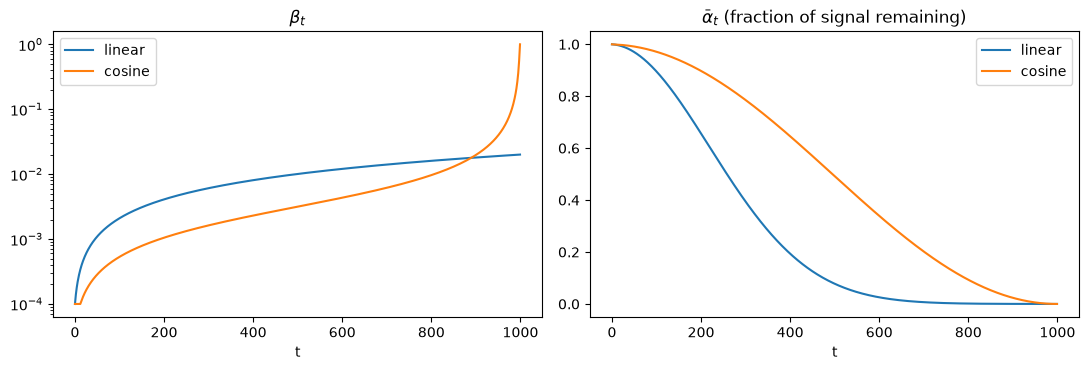

linear: share of timesteps with alpha_bar < 0.001 (almost pure noise): 17.5%
cosine: share of timesteps with alpha_bar < 0.001 (almost pure noise): 2.1%


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for name, s in scheds.items():
    ax[0].plot(s['betas'].cpu(), label=name)
    ax[1].plot(s['alpha_bars'].cpu(), label=name)
ax[0].set_title(r'$\beta_t$'); ax[0].set_yscale('log'); ax[0].set_xlabel('t'); ax[0].legend()
ax[1].set_title(r'$\bar\alpha_t$ (fraction of signal remaining)'); ax[1].set_xlabel('t'); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig1_schedules.png'), dpi=200, bbox_inches='tight'); plt.show()

for name, s in scheds.items():
    ab = s['alpha_bars'].cpu()
    frac_dead = (ab < 1e-3).float().mean().item()
    print(f"{name:>6}: share of timesteps with alpha_bar < 0.001 (almost pure noise): {frac_dead:.1%}")

## Figure 2: training loss

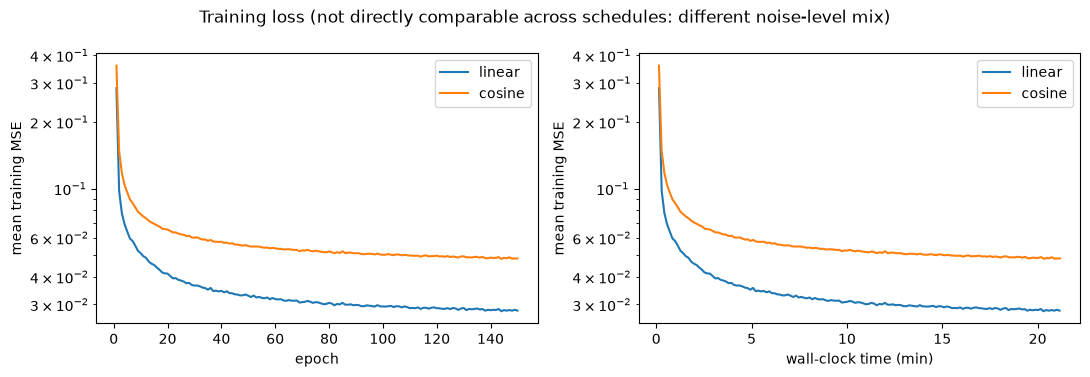

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for name, ck in ckpts.items():
    ax[0].plot(range(1, len(ck['epoch_losses']) + 1), ck['epoch_losses'], label=name)
    ax[1].plot(np.array(ck['epoch_times_s']) / 60, ck['epoch_losses'], label=name)
ax[0].set_xlabel('epoch'); ax[1].set_xlabel('wall-clock time (min)')
for a in ax:
    a.set_ylabel('mean training MSE'); a.set_yscale('log'); a.legend()
plt.suptitle('Training loss (not directly comparable across schedules: different noise-level mix)')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig2_training_loss.png'), dpi=200, bbox_inches='tight'); plt.show()

## Figures 3 and 4: 12 samples per digit (120 images per model), full T = 1000 steps
DDPM ancestral sampling over all 1000 steps, with the predicted clean image clipped to [-1, 1] at every step (see the step-count experiment below for why). Both models use the same starting noise (same seed).

Sampling (linear, 1000 steps): 100%|██████████| 1000/1000 [00:11<00:00, 90.17it/s]


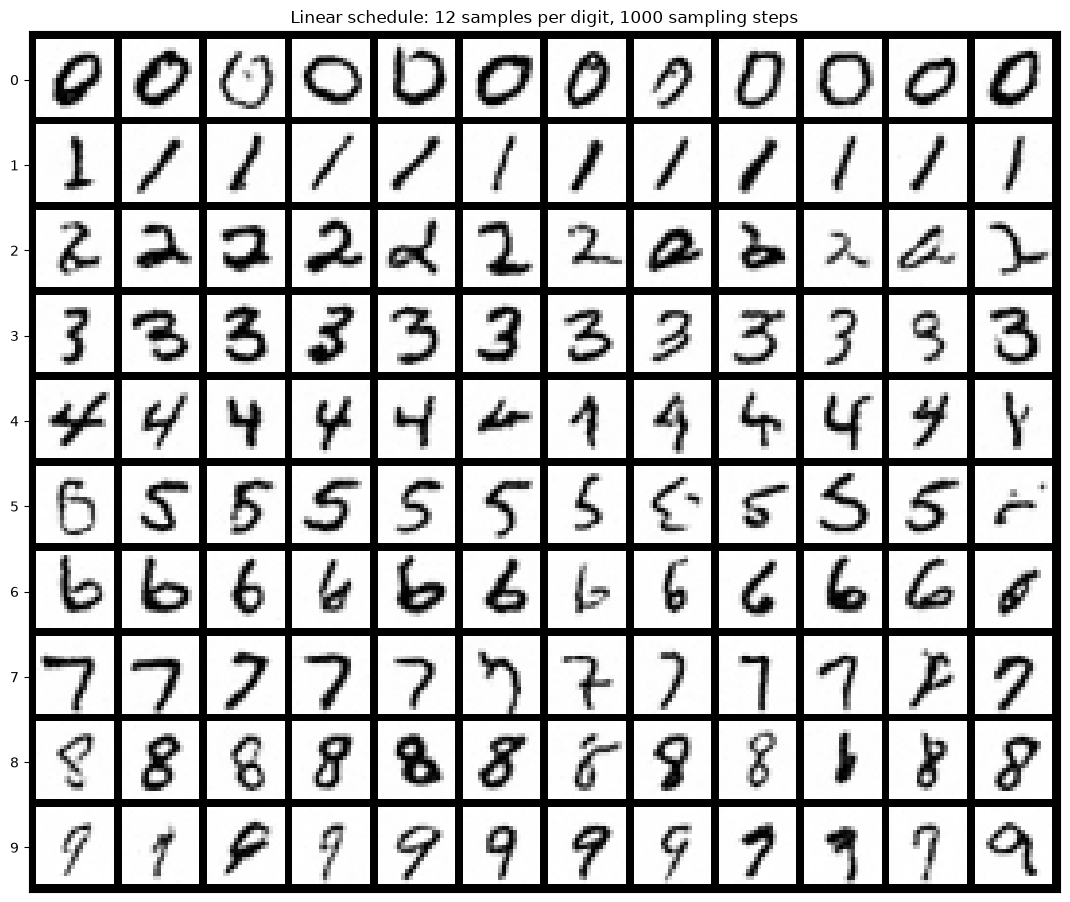

Sampling (cosine, 1000 steps): 100%|██████████| 1000/1000 [00:10<00:00, 91.80it/s]


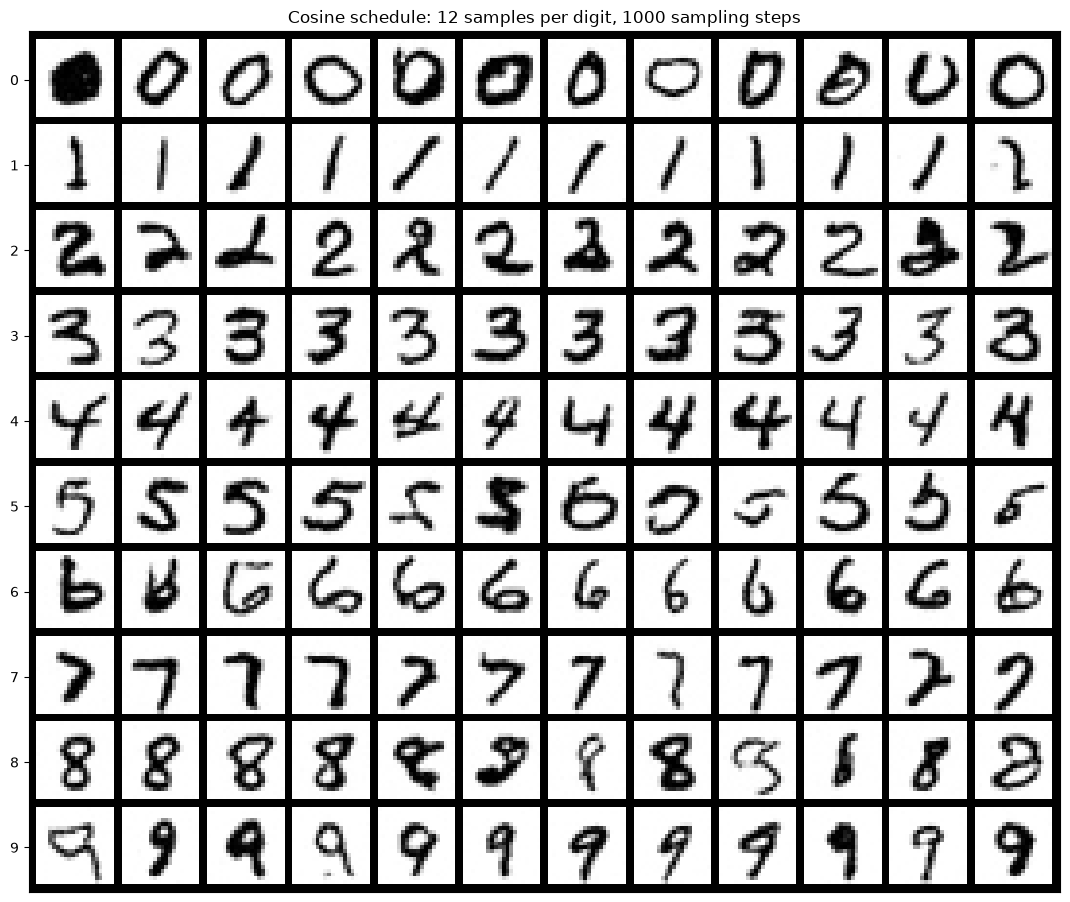

In [13]:
sample_per_class = 12
labels = torch.arange(0, 10).repeat_interleave(sample_per_class).to(device)
full_samples = {}
for i, name in enumerate(['linear', 'cosine']):
    full_samples[name] = p_sample_loop_respaced(models[name], labels, scheds[name], n_steps=scheds[name]['T'], seed=SAMPLE_SEED, clip_denoised=True, show_progress=True)
    show_digit_grid(full_samples[name], sample_per_class, list(range(10)),
                    f'{name.capitalize()} schedule: 12 samples per digit, {scheds[name]["T"]} sampling steps',
                    save_path=os.path.join(FIG_DIR, f'fig{3+i}_grid_{name}_T1000.png'))

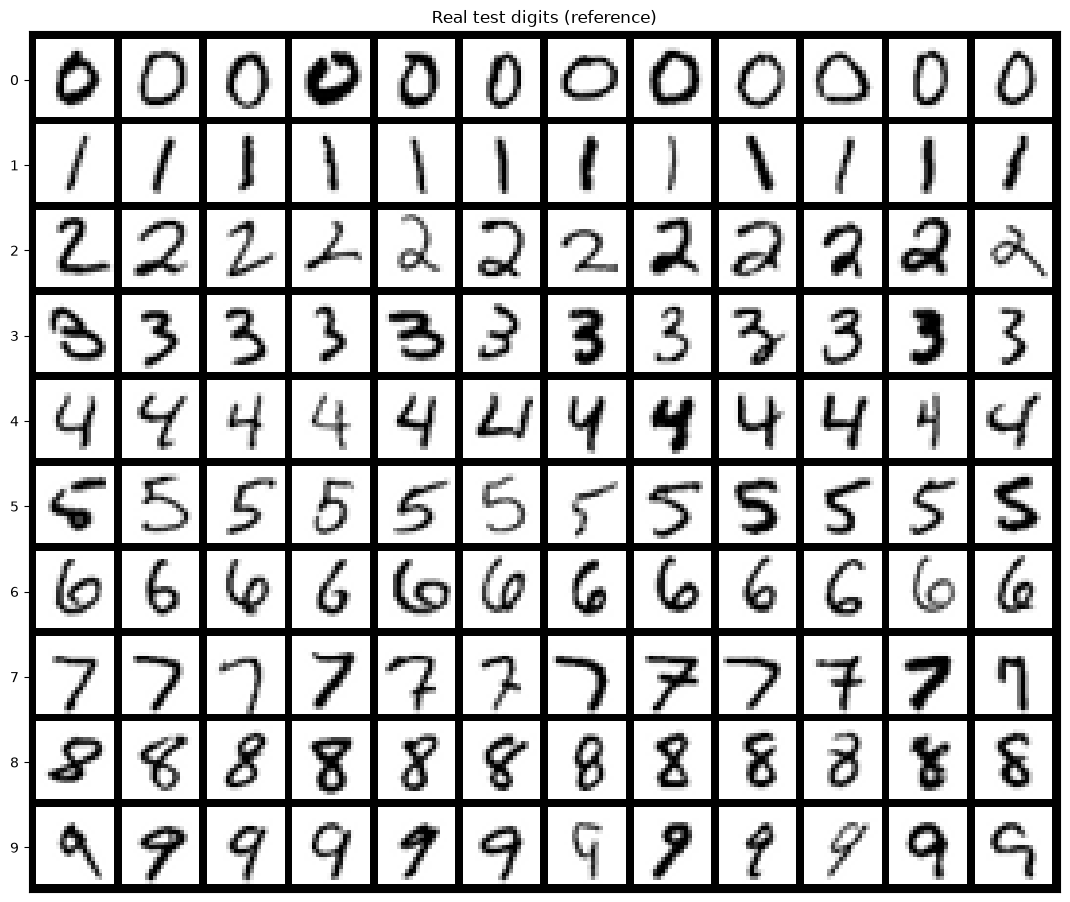

In [14]:
# Optional reference: real digits (only if the dataset file is present)
if os.path.exists('mnist_custom.pt'):
    data = torch.load('mnist_custom.pt')
    xs = {k: v for k, v in data.items() if 'test' in k.lower() and torch.is_tensor(v)}
    x_test = [v for v in xs.values() if v.dim() >= 3][0].float()
    y_test = [v for v in xs.values() if v.dim() == 1][0].long()
    if x_test.min() >= 0:
        x_test = (x_test / 255.0 if x_test.max() > 1 else x_test) * 2 - 1
    if x_test.dim() == 3:
        x_test = x_test.unsqueeze(1)
    real = torch.cat([x_test[y_test == c][:sample_per_class] for c in range(10)])
    show_digit_grid(real, sample_per_class, list(range(10)), 'Real test digits (reference)',
                    save_path=os.path.join(FIG_DIR, 'grid_real.png'))
else:
    print('mnist_custom.pt not found: skipping the real-digit reference grid.')

## Experiment: quality as the number of sampling steps decreases
Each model was trained with T = 1000. For K ∈ {1000, 500, 250, 100, 50, 25, 10} we sample with **timestep respacing** (Nichol & Dhariwal, 2021): K evenly spaced steps of the original schedule, with $\beta$ recomputed from $\bar\alpha$. For each (schedule, K) we generate `N_EVAL_PER_CLASS` digits per class with the same seed and report:

* **Conditional accuracy**: share of generated digits that the classifier assigns to the requested class.
* **Confidence**: mean classifier probability of the requested class (higher means a more clearly drawn digit).
* **Within-class diversity**: mean pairwise L2 distance between samples of the same class. A value near 0 would indicate mode collapse.
* **Sampling time** in seconds.

Each (schedule, K) is run **twice**: with the tutorial's update rule (no clipping) and with the predicted clean image clipped to [-1, 1] (as in the official code of Ho et al., 2020 and Nichol & Dhariwal, 2021).

First, a sanity check that respacing with K = T and no clipping reproduces the standard sampler.

In [15]:
y_chk = torch.arange(10, device=device)
a = p_sample_loop_cDDPM(models['cosine'], y_chk, scheds['cosine'], seed=0, show_progress=False)
b = p_sample_loop_respaced(models['cosine'], y_chk, scheds['cosine'], n_steps=scheds['cosine']['T'], seed=0, clip_denoised=False)
print(f'max |standard - respaced(K=T, no clipping)| = {(a - b).abs().max().item():.2e}  (small: float rounding only)')

max |standard - respaced(K=T, no clipping)| = 1.45e-03  (small: float rounding only)


### Why clipping matters: error amplification at the first reverse step
The tutorial's update divides by $\sqrt{1-\beta'_t}$. For the cosine schedule the noisiest kept step has $\beta' \approx 1$ (the schedule is clipped at $\beta = 0.999$ and $\bar\alpha_T \approx 10^{-9}$), so any error in the predicted noise is multiplied by a large factor. Respacing makes this worse. The linear schedule never gets close to $\beta' = 1$.

In [16]:
rows = []
for K in [1000, 500, 250, 100, 50, 25, 10]:
    row = {'steps K': K}
    for name, s in scheds.items():
        T = s['T']
        use_t = torch.linspace(0, T - 1, K, device=device).round().long()
        ab = s['alpha_bars'][use_t]
        beta_first = 1 - ab[-1] / ab[-2]
        row[f'{name}: error amplification'] = round((1 / torch.sqrt(1 - beta_first)).item(), 1)
    rows.append(row)
amp_table = pd.DataFrame(rows).set_index('steps K')
amp_table.to_csv(os.path.join(RES_DIR, 'first_step_amplification.csv'))
amp_table

,linear: error amplification,cosine: error amplification
steps K,,
1000,1.0,31.6
500,1.0,63.2
250,1.0,126.5
100,1.1,316.0
50,1.2,632.0
25,1.5,1295.3
10,2.9,4096.0


In [17]:
STEPS = [1000, 500, 250, 100, 50, 25, 10]
N_EVAL_PER_CLASS = 50     # 500 images per (schedule, K)

@torch.no_grad()
def within_class_diversity(x, y):
    d = []
    for c in range(10):
        xc = x[y == c].flatten(1)
        n = len(xc)
        if n > 1:
            d.append(torch.cdist(xc, xc).sum() / (n * (n - 1)))
    return torch.stack(d).mean().item()

@torch.no_grad()
def evaluate(samples, y):
    probs = F.softmax(clf(samples), dim=1)
    acc = (probs.argmax(1) == y).float().mean().item()
    conf = probs.gather(1, y.unsqueeze(1)).mean().item()
    return acc, conf

y_eval = torch.arange(10, device=device).repeat_interleave(N_EVAL_PER_CLASS)
results = []
for clip in [False, True]:
    for name in ['linear', 'cosine']:
        for K in tqdm(STEPS, desc=f'{name}, clip={clip}: step sweep', colour='BLUE'):
            if device.type == 'cuda': torch.cuda.synchronize()
            t0 = time.time()
            s = p_sample_loop_respaced(models[name], y_eval, scheds[name], n_steps=K, seed=SAMPLE_SEED, clip_denoised=clip)
            if device.type == 'cuda': torch.cuda.synchronize()
            dt = time.time() - t0
            acc, conf = evaluate(s, y_eval)
            results.append({'clipping': 'clip x0' if clip else 'no clip', 'schedule': name, 'steps K': K,
                            'cond. accuracy': acc, 'confidence': conf,
                            'diversity (L2)': within_class_diversity(s, y_eval), 'sampling time (s)': dt})

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(RES_DIR, 'step_sweep.csv'), index=False)
results_df.pivot(index='steps K', columns=['clipping', 'schedule'],
                 values=['cond. accuracy', 'confidence']).sort_index(ascending=False).round(3)

cosine, clip=True: step sweep: 100%|██████████| 7/7 [01:22<00:00, 11.84s/it]


cond. accuracy                       confidence                      
clipping        no clip        clip x0           no clip        clip x0       
schedule         linear cosine  linear cosine     linear cosine  linear cosine
steps K                                                                       
1000              0.958  0.922   0.956  0.922      0.949  0.919   0.946  0.921
500               0.952  0.916   0.948  0.932      0.939  0.904   0.936  0.924
250               0.940  0.706   0.940  0.932      0.933  0.680   0.932  0.927
100               0.956  0.138   0.944  0.946      0.947  0.133   0.941  0.943
50                0.944  0.100   0.950  0.958      0.937  0.102   0.937  0.943
25                0.962  0.102   0.958  0.944      0.947  0.095   0.943  0.930
10                0.904  0.100   0.900  0.882      0.850  0.101   0.845  0.856

## Figure 5: quality vs number of sampling steps

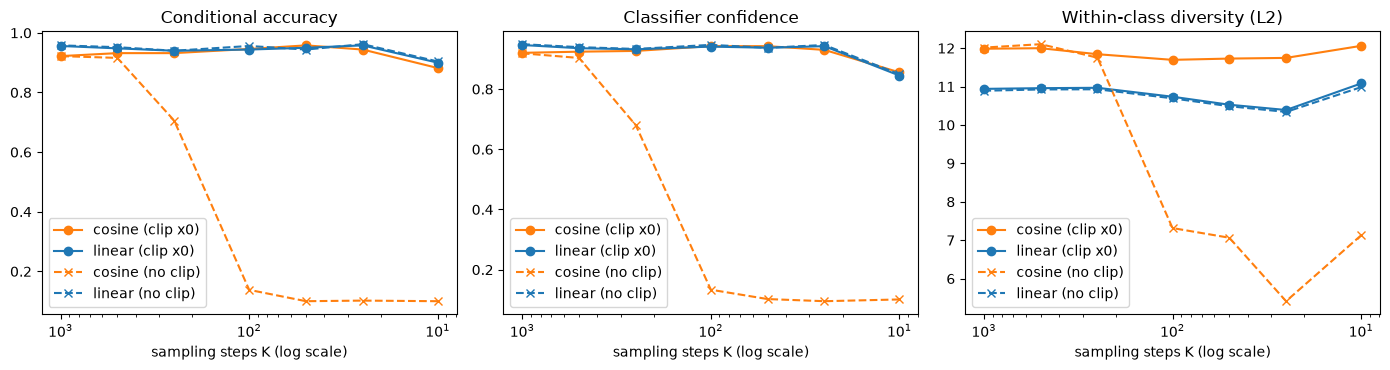

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
colors = {'linear': 'tab:blue', 'cosine': 'tab:orange'}
for (clip, name), g in results_df.groupby(['clipping', 'schedule']):
    g = g.sort_values('steps K')
    style = 'o-' if clip == 'clip x0' else 'x--'
    for a, col in zip(ax, ['cond. accuracy', 'confidence', 'diversity (L2)']):
        a.plot(g['steps K'], g[col], style, color=colors[name], label=f'{name} ({clip})')
for a, t in zip(ax, ['Conditional accuracy', 'Classifier confidence', 'Within-class diversity (L2)']):
    a.set_xscale('log'); a.set_xlabel('sampling steps K (log scale)'); a.set_title(t); a.legend()
    a.invert_xaxis()   # fewer steps to the right
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig5_quality_vs_steps.png'), dpi=200, bbox_inches='tight'); plt.show()

## Figure 6: visual comparison at decreasing step counts (same seed, one row per K)

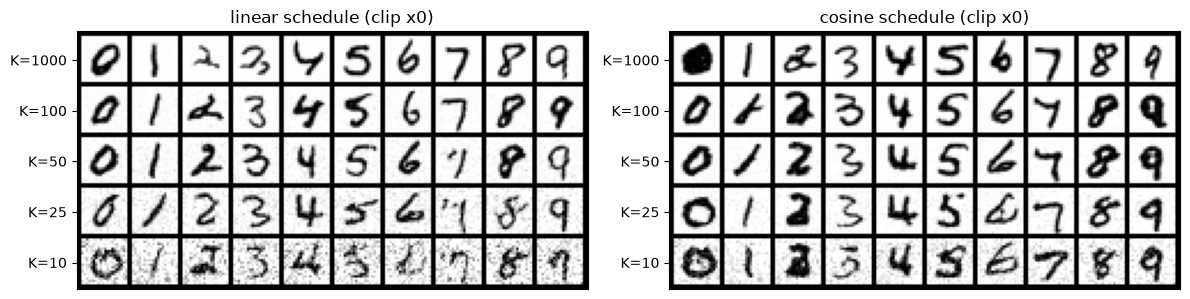

In [19]:
K_show = [1000, 100, 50, 25, 10]
y_row = torch.arange(10, device=device)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for j, name in enumerate(['linear', 'cosine']):
    rows = [p_sample_loop_respaced(models[name], y_row, scheds[name], n_steps=K, seed=SAMPLE_SEED, clip_denoised=True) for K in K_show]
    grid = utils.make_grid((torch.cat(rows) + 1) / 2, nrow=10, padding=2)
    ax[j].imshow(grid.permute(1, 2, 0).cpu())
    ax[j].set_yticks([2 + (image_size + 2) * i + image_size / 2 for i in range(len(K_show))])
    ax[j].set_yticklabels([f'K={K}' for K in K_show]); ax[j].set_xticks([])
    ax[j].set_title(f'{name} schedule (clip x0)')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig6_steps_visual.png'), dpi=200, bbox_inches='tight'); plt.show()

## Figures 7 and 8: 12 × 10 grids at a reduced step budget
The same 120-image layout as Figures 3–4, but sampled with only `K_LOW` respaced steps, to show directly what "fewer time steps" does to each model.

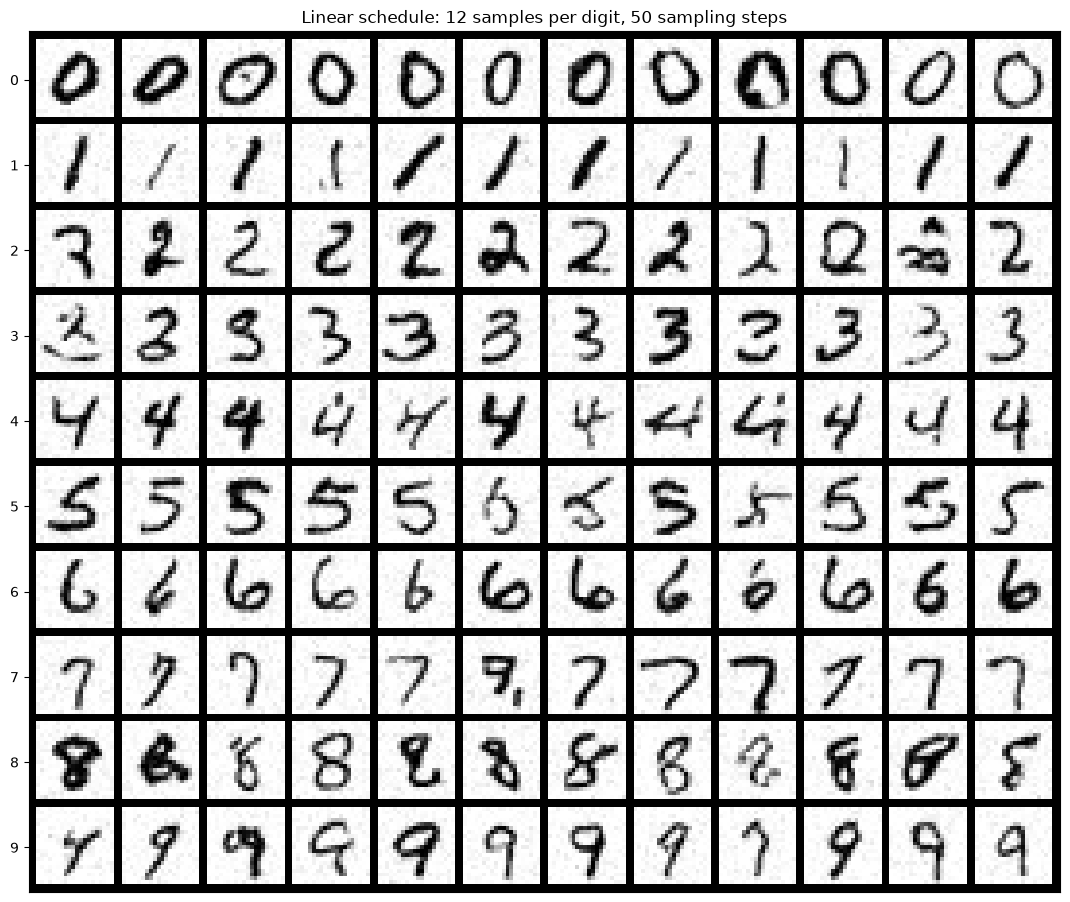

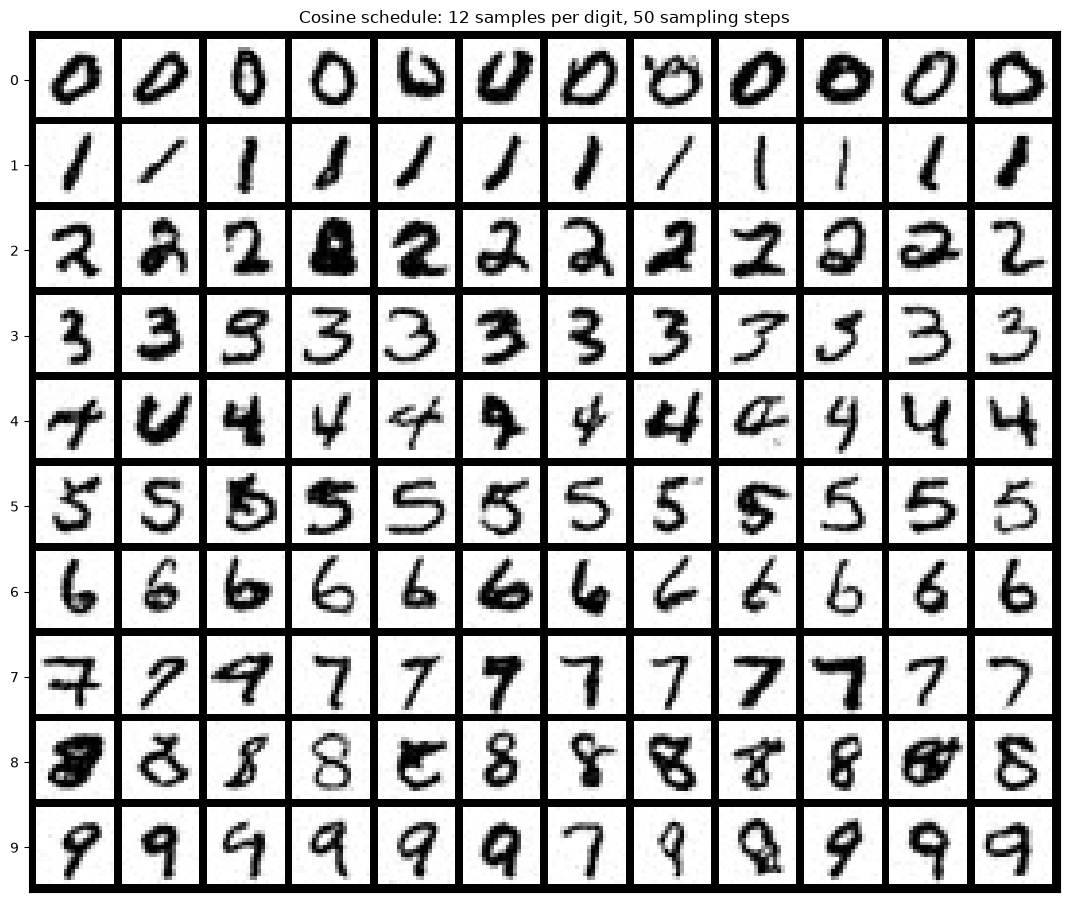

In [20]:
K_LOW = 50
for i, name in enumerate(['linear', 'cosine']):
    s = p_sample_loop_respaced(models[name], labels, scheds[name], n_steps=K_LOW, seed=SAMPLE_SEED, clip_denoised=True)
    show_digit_grid(s, sample_per_class, list(range(10)),
                    f'{name.capitalize()} schedule: 12 samples per digit, {K_LOW} sampling steps',
                    save_path=os.path.join(FIG_DIR, f'fig{7+i}_grid_{name}_K{K_LOW}.png'))